# Softmax and temperature-scaling baselines

Issue #6. This notebook measures the reliability baselines SDM has to beat:
plain softmax confidence and temperature scaling, scored with accuracy,
NLL, expected calibration error (ECE), and risk-coverage curves.

It reads the exported logits in `calibration_outputs_full.npz` and
`test_outputs_full.npz` produced by notebook 02. It trains nothing.

Discipline: the temperature and the abstention threshold are fit on
calibration data only. Test data is touched once, at the end, with those
fixed values. Nothing here is tuned against test.

Reproduce:

```bash
python3 -m jupyter nbconvert --to notebook --execute \
  notebooks/03_softmax_temperature_baselines.ipynb \
  --output /tmp/03_executed.ipynb
```

Override the run directory with `SDM_RUN_DIR` if your notebook-02 outputs
live elsewhere.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

RUN_DIR = Path(
    os.environ.get(
        "SDM_RUN_DIR",
        Path.home()
        / ".cache"
        / "sdm-vision-reliability"
        / "runs"
        / "convnext_tiny_imagenet1k_v1"
        / "seed_42"
        / "benchmark",
    )
).expanduser()
CAL_PATH = RUN_DIR / "calibration_outputs_full.npz"
TEST_PATH = RUN_DIR / "test_outputs_full.npz"

missing = [p for p in (CAL_PATH, TEST_PATH) if not p.exists()]
if missing:
    raise FileNotFoundError(
        "Missing exported outputs: "
        + ", ".join(str(p) for p in missing)
        + ". Run notebook 02 (benchmark mode) first, or point SDM_RUN_DIR "
        + "at a directory containing them."
    )

cal = np.load(CAL_PATH)
test = np.load(TEST_PATH)
cal_logits, cal_targets = cal["logits"], cal["targets"].astype(np.int64)
test_logits, test_targets = test["logits"], test["targets"].astype(np.int64)
print(f"calibration: logits {cal_logits.shape}, targets {cal_targets.shape}")
print(f"test:        logits {test_logits.shape}, targets {test_targets.shape}")
assert cal_logits.shape[1] == 100 and test_logits.shape[1] == 100

calibration: logits (2500, 100), targets (2500,)
test:        logits (10000, 100), targets (10000,)


## Temperature scaling

One scalar `T`, fit by minimizing NLL on calibration logits only (Guo et
al., 2017). `T > 1` softens overconfident probabilities; accuracy is
unchanged because scaling preserves the argmax.

In [2]:
def softmax_with_temperature(logits: np.ndarray, temperature: float) -> np.ndarray:
    logits = np.asarray(logits, dtype=np.float64)
    scaled = logits / temperature
    shifted = scaled - scaled.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    return exp / exp.sum(axis=1, keepdims=True)


def fit_temperature(logits: np.ndarray, labels: np.ndarray, max_iter: int = 200) -> float:
    logits_t = torch.from_numpy(np.ascontiguousarray(logits))
    labels_t = torch.from_numpy(np.ascontiguousarray(labels))
    # Optimize log-temperature so T stays positive by construction; an
    # unconstrained T can step negative and invert every prediction.
    log_temperature = nn.Parameter(torch.zeros(1))
    optimizer = torch.optim.LBFGS([log_temperature], lr=0.5, max_iter=max_iter)
    loss_fn = nn.CrossEntropyLoss()

    def closure():
        optimizer.zero_grad()
        loss = loss_fn(logits_t / torch.exp(log_temperature), labels_t)
        loss.backward()
        return loss

    optimizer.step(closure)
    return float(torch.exp(log_temperature).detach().item())


def negative_log_likelihood(probs: np.ndarray, labels: np.ndarray) -> float:
    eps = 1e-12
    picked = np.clip(probs[np.arange(len(labels)), labels], eps, 1.0)
    return float(-np.log(picked).mean())


def expected_calibration_error(
    probs: np.ndarray, labels: np.ndarray, n_bins: int = 15
) -> float:
    confidences = probs.max(axis=1)
    correct = (probs.argmax(axis=1) == labels).astype(float)
    bounds = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for low, high in zip(bounds[:-1], bounds[1:]):
        in_bin = (confidences > low) & (confidences <= high)
        if in_bin.sum() > 0:
            ece += in_bin.mean() * abs(correct[in_bin].mean() - confidences[in_bin].mean())
    return float(ece)


def top1_accuracy(probs: np.ndarray, labels: np.ndarray) -> float:
    return float((probs.argmax(axis=1) == labels).mean())


TEMPERATURE = fit_temperature(cal_logits, cal_targets)
print(f"temperature fit on calibration only: T = {TEMPERATURE:.4f}")

cal_raw = softmax_with_temperature(cal_logits, 1.0)
cal_scaled = softmax_with_temperature(cal_logits, TEMPERATURE)
test_raw = softmax_with_temperature(test_logits, 1.0)
test_scaled = softmax_with_temperature(test_logits, TEMPERATURE)

temperature fit on calibration only: T = 0.8628


In [3]:
rows = [
    ("calibration", "softmax", cal_raw, cal_targets),
    ("calibration", "temp-scaled", cal_scaled, cal_targets),
    ("test", "softmax", test_raw, test_targets),
    ("test", "temp-scaled", test_scaled, test_targets),
]
print(f"{'split':<12}{'method':<12}{'top-1':>8}{'NLL':>8}{'ECE':>8}")
for split, method, probs, labels in rows:
    print(
        f"{split:<12}{method:<12}"
        f"{top1_accuracy(probs, labels):>8.2%}"
        f"{negative_log_likelihood(probs, labels):>8.4f}"
        f"{expected_calibration_error(probs, labels):>8.4f}"
    )

split       method         top-1     NLL     ECE
calibration softmax       89.48%  0.4737  0.0686
calibration temp-scaled   89.48%  0.4452  0.0366
test        softmax       89.14%  0.4925  0.0614
test        temp-scaled   89.14%  0.4651  0.0327


## Selective classification

Admit a prediction when its confidence (max probability) clears a threshold,
abstain otherwise. Coverage is the fraction admitted; accepted accuracy is
accuracy on the admitted subset. A threshold picked on calibration is applied
to test unchanged — that is the only honest way to report coverage at the 95%
accepted-accuracy target.

If no calibration threshold reaches 95% with enough admitted examples to
trust, the target is reported as unattainable rather than fudged.

In [4]:
MIN_ADMITTED = 100  # fewest calibration admissions trusted for threshold picking
TARGET_ACCEPTED_ACCURACY = 0.95
FIXED_THRESHOLDS = (0.0, 0.5, 0.7, 0.8, 0.9)


def admitted_stats(confidences: np.ndarray, correct: np.ndarray, threshold: float) -> dict:
    admitted = confidences >= threshold
    n = int(admitted.sum())
    return {
        "coverage": float(admitted.mean()),
        "accepted_accuracy": float(correct[admitted].mean()) if n else float("nan"),
        "n_admitted": n,
    }


def risk_coverage_curve(
    confidences: np.ndarray, correct: np.ndarray, grid: int = 1000
) -> tuple[np.ndarray, np.ndarray]:
    thresholds = np.linspace(0.0, 1.0, grid)
    coverage = np.array([(confidences >= t).mean() for t in thresholds])
    accepted = np.array(
        [
            correct[confidences >= t].mean() if (confidences >= t).any() else np.nan
            for t in thresholds
        ]
    )
    return coverage, accepted


def threshold_for_target(
    confidences: np.ndarray, correct: np.ndarray, target: float
) -> float | None:
    """Highest threshold whose calibration admissions clear the target accuracy."""
    order = np.argsort(-confidences)
    sorted_correct = correct[order]
    cumulative = np.cumsum(sorted_correct) / np.arange(1, len(sorted_correct) + 1)
    ok = np.flatnonzero(cumulative >= target)
    ok = ok[ok + 1 >= MIN_ADMITTED]
    if len(ok) == 0:
        return None
    # Admit the largest prefix that still clears the target: threshold is the
    # confidence of the last admitted example.
    return float(confidences[order[ok[-1]]])


cal_conf_raw = cal_raw.max(axis=1)
cal_conf_scaled = cal_scaled.max(axis=1)
test_conf_raw = test_raw.max(axis=1)
test_conf_scaled = test_scaled.max(axis=1)
cal_correct_raw = (cal_raw.argmax(axis=1) == cal_targets)
cal_correct_scaled = (cal_scaled.argmax(axis=1) == cal_targets)
test_correct_raw = (test_raw.argmax(axis=1) == test_targets)
test_correct_scaled = (test_scaled.argmax(axis=1) == test_targets)
# Scaling preserves the argmax mathematically, but near-tied top logits can
# flip in floating point, so each method is scored with its own correctness.
for _name, _a, _b in (("calibration", cal_correct_raw, cal_correct_scaled), ("test", test_correct_raw, test_correct_scaled)):
    _flips = int((_a != _b).sum())
    if _flips:
        print(f"note: {_flips} {_name} predictions flipped argmax under scaling (float ties)")

print(f"{'threshold':<10}{'raw cov':>9}{'raw acc':>9}{'scaled cov':>11}{'scaled acc':>11}")
for threshold in FIXED_THRESHOLDS:
    s_raw = admitted_stats(test_conf_raw, test_correct_raw, threshold)
    s_scaled = admitted_stats(test_conf_scaled, test_correct_scaled, threshold)
    print(
        f"{threshold:<10.2f}{s_raw['coverage']:>9.2%}{s_raw['accepted_accuracy']:>9.2%}"
        f"{s_scaled['coverage']:>11.2%}{s_scaled['accepted_accuracy']:>11.2%}"
    )

print()
for name, cal_conf, cal_ok, test_conf, test_ok in (
    ("softmax", cal_conf_raw, cal_correct_raw, test_conf_raw, test_correct_raw),
    ("temp-scaled", cal_conf_scaled, cal_correct_scaled, test_conf_scaled, test_correct_scaled),
):
    threshold = threshold_for_target(cal_conf, cal_ok, TARGET_ACCEPTED_ACCURACY)
    if threshold is None:
        print(f"{name}: 95% accepted-accuracy target UNATTAINABLE on calibration")
        continue
    cal_stats = admitted_stats(cal_conf, cal_ok, threshold)
    test_stats = admitted_stats(test_conf, test_ok, threshold)
    print(
        f"{name}: threshold {threshold:.4f} from calibration "
        f"(cal: {cal_stats['coverage']:.2%} coverage at {cal_stats['accepted_accuracy']:.2%}) -> "
        f"test: {test_stats['coverage']:.2%} coverage at {test_stats['accepted_accuracy']:.2%} "
        f"(n={test_stats['n_admitted']})"
    )

threshold   raw cov  raw acc scaled cov scaled acc
0.00        100.00%   89.14%    100.00%     89.14%
0.50         95.47%   91.68%     97.41%     90.70%
0.70         89.68%   94.30%     92.95%     92.88%
0.80         85.46%   95.58%     89.92%     94.21%
0.90         59.87%   98.08%     85.13%     95.70%

softmax: threshold 0.7501 from calibration (cal: 88.48% coverage at 95.03%) -> test: 87.93% coverage at 94.91% (n=8793)
temp-scaled: threshold 0.8527 from calibration (cal: 88.40% coverage at 95.02%) -> test: 88.00% coverage at 94.85% (n=8800)


saved /Users/karimmattar11/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/figures_03_baselines.png


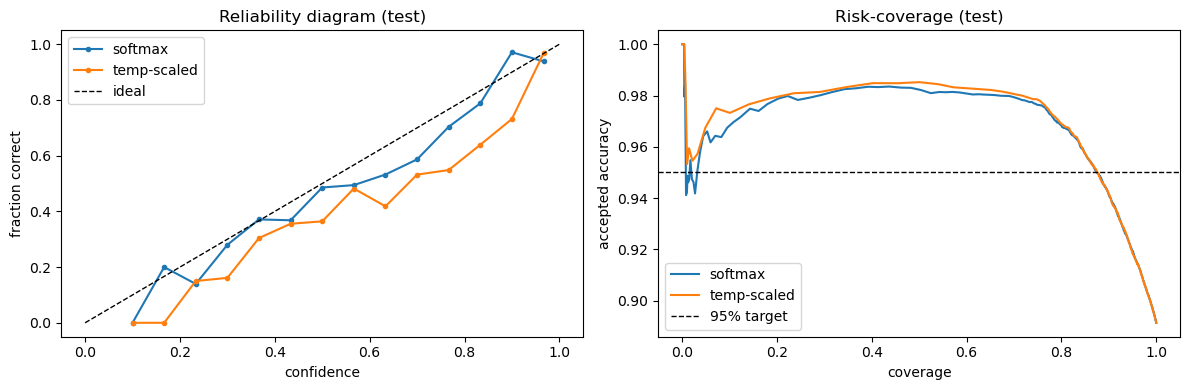

In [5]:
cov_raw, acc_raw = risk_coverage_curve(test_conf_raw, test_correct_raw)
cov_scaled, acc_scaled = risk_coverage_curve(test_conf_scaled, test_correct_scaled)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

bounds = np.linspace(0.0, 1.0, 16)
centers = (bounds[:-1] + bounds[1:]) / 2
for probs, label in ((test_raw, "softmax"), (test_scaled, "temp-scaled")):
    conf = probs.max(axis=1)
    corr = (probs.argmax(axis=1) == test_targets).astype(float)
    frac_pos = np.array(
        [
            corr[(conf > lo) & (conf <= hi)].mean()
            if ((conf > lo) & (conf <= hi)).any()
            else np.nan
            for lo, hi in zip(bounds[:-1], bounds[1:])
        ]
    )
    axes[0].plot(centers, frac_pos, marker="o", markersize=3, label=label)
axes[0].plot([0, 1], [0, 1], "k--", linewidth=1, label="ideal")
axes[0].set_xlabel("confidence")
axes[0].set_ylabel("fraction correct")
axes[0].set_title("Reliability diagram (test)")
axes[0].legend()

axes[1].plot(cov_raw, acc_raw, label="softmax")
axes[1].plot(cov_scaled, acc_scaled, label="temp-scaled")
axes[1].axhline(0.95, color="k", linestyle="--", linewidth=1, label="95% target")
axes[1].set_xlabel("coverage")
axes[1].set_ylabel("accepted accuracy")
axes[1].set_title("Risk-coverage (test)")
axes[1].legend()

fig.tight_layout()
figures_path = RUN_DIR / "figures_03_baselines.png"
fig.savefig(figures_path, dpi=150)
print(f"saved {figures_path}")
plt.show()

In [6]:
metrics = {
    "temperature": TEMPERATURE,
    "fit_on": "calibration only",
    "metrics": {
        "calibration_softmax": {
            "top1": top1_accuracy(cal_raw, cal_targets),
            "nll": negative_log_likelihood(cal_raw, cal_targets),
            "ece": expected_calibration_error(cal_raw, cal_targets),
        },
        "calibration_scaled": {
            "top1": top1_accuracy(cal_scaled, cal_targets),
            "nll": negative_log_likelihood(cal_scaled, cal_targets),
            "ece": expected_calibration_error(cal_scaled, cal_targets),
        },
        "test_softmax": {
            "top1": top1_accuracy(test_raw, test_targets),
            "nll": negative_log_likelihood(test_raw, test_targets),
            "ece": expected_calibration_error(test_raw, test_targets),
        },
        "test_scaled": {
            "top1": top1_accuracy(test_scaled, test_targets),
            "nll": negative_log_likelihood(test_scaled, test_targets),
            "ece": expected_calibration_error(test_scaled, test_targets),
        },
    },
}
metrics_path = RUN_DIR / "metrics_03_baselines.json"
metrics_path.write_text(json.dumps(metrics, indent=2) + "\n")
print(f"saved {metrics_path}")
print(json.dumps(metrics, indent=2))

saved /Users/karimmattar11/.cache/sdm-vision-reliability/runs/convnext_tiny_imagenet1k_v1/seed_42/benchmark/metrics_03_baselines.json
{
  "temperature": 0.8628079891204834,
  "fit_on": "calibration only",
  "metrics": {
    "calibration_softmax": {
      "top1": 0.8948,
      "nll": 0.4736980737922254,
      "ece": 0.06863668377366478
    },
    "calibration_scaled": {
      "top1": 0.8948,
      "nll": 0.44517672275089554,
      "ece": 0.03659611818834559
    },
    "test_softmax": {
      "top1": 0.8914,
      "nll": 0.49247497795944956,
      "ece": 0.06140981846757364
    },
    "test_scaled": {
      "top1": 0.8914,
      "nll": 0.4651290333869204,
      "ece": 0.03272948723871856
    }
  }
}


## Reading the results

What to look for:

- Temperature above 1 with lower test ECE means the model was overconfident
  and scaling helped. If ECE barely moves, say so.
- The risk-coverage curves are the baseline SDM must beat: at any coverage,
  SDM's accepted accuracy has to clear these lines to claim anything.
- The 95%-target line reports what coverage each method buys at 95%
  accepted accuracy, with the threshold carried over from calibration
  untouched. If the target is unattainable, that is the finding.

Issue #6 acceptance covered here: temperature fit on calibration only,
clean accuracy / calibration / risk-coverage reported, exact reproduction
command at the top. Still open after this: CIFAR-100-C, SVHN, and the
Schmaltz-meeting notes.